# IT4060 - HPC Failure Prediction

## Notebook: Model Comparison

This notebook compares the saved results from the model notebooks using the same processed dataset, chronological split, and exported evaluation artifacts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)


In [2]:
PROJECT_NAME = 'IT4060-ML-Assignment-HPC-Failure-Prediction'
MODEL_DISPLAY_NAMES = {
    'logistic_regression_baseline': 'Logistic Regression',
    'random_forest': 'Random Forest',
    'hist_gradient_boosting': 'Hist Gradient Boosting',
    'extra_trees': 'Extra Trees',
    'linear_svc': 'Linear SVC',
}
DISPLAY_ORDER = [
    'logistic_regression_baseline',
    'random_forest',
    'hist_gradient_boosting',
    'extra_trees',
    'linear_svc',
]
PRIMARY_METRIC = 'pr_auc'

def find_project_root():
    cwd = Path.cwd().resolve()
    home = Path.home().resolve()
    desktop = home / 'Desktop'
    candidate_roots = [cwd, *cwd.parents, home, desktop, desktop / 'Manilka' / 'ML_Assignment']
    seen = set()

    for base in candidate_roots:
        for candidate in (base, base / PROJECT_NAME):
            if candidate in seen or not candidate.exists():
                continue
            seen.add(candidate)
            if (candidate / 'results').exists():
                return candidate

    raise FileNotFoundError('Could not locate the project root with results/.')

project_root = find_project_root()
results_dir = project_root / 'results'
comparison_results_dir = results_dir / 'model_comparison'
comparison_results_dir.mkdir(parents=True, exist_ok=True)

catalog_path = comparison_results_dir / 'model_catalog.csv'
validation_combined_path = comparison_results_dir / 'validation_metrics_combined.csv'
test_combined_path = comparison_results_dir / 'test_metrics_combined.csv'
default_summary_path = comparison_results_dir / 'test_default_threshold_summary.csv'
best_summary_path = comparison_results_dir / 'test_best_threshold_summary.csv'
ranking_path = comparison_results_dir / 'model_ranking.csv'
overview_plot_path = comparison_results_dir / 'test_metric_overview.png'
threshold_plot_path = comparison_results_dir / 'threshold_strategy_comparison.png'
ranking_plot_path = comparison_results_dir / 'ranking_signal_comparison.png'

print(f'Working directory: {Path.cwd()}')
print(f'Project root: {project_root}')
print(f'Results directory: {results_dir}')
print(f'Comparison results directory: {comparison_results_dir}')
print(f'Models compared: {', '.join(DISPLAY_ORDER)}')


Working directory: c:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\notebooks
Project root: C:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction
Results directory: C:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\results
Comparison results directory: C:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\results\model_comparison
Models compared: logistic_regression_baseline, random_forest, hist_gradient_boosting, extra_trees, linear_svc


In [3]:
catalog_rows = []
validation_frames = []
test_frames = []

for model_name in DISPLAY_ORDER:
    model_dir = results_dir / model_name
    metadata_path = model_dir / 'run_metadata.csv'
    validation_path = model_dir / 'validation_metrics.csv'
    test_path = model_dir / 'test_metrics.csv'

    if not (metadata_path.exists() and validation_path.exists() and test_path.exists()):
        raise FileNotFoundError(f'Missing expected result files for {model_name}: {model_dir}')

    metadata_df = pd.read_csv(metadata_path)
    validation_df = pd.read_csv(validation_path)
    test_df = pd.read_csv(test_path)

    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)
    metadata_df = metadata_df.copy()
    metadata_df['model_name'] = model_name
    metadata_df['display_name'] = display_name
    metadata_df = metadata_df[['model_name', 'display_name', *[column for column in metadata_df.columns if column not in {'model_name', 'display_name'}]]]
    catalog_rows.append(metadata_df.iloc[0].to_dict())

    validation_df = validation_df.copy()
    validation_df.insert(0, 'model_name', model_name)
    validation_df.insert(1, 'display_name', display_name)
    validation_df.insert(2, 'threshold_strategy', ['default', 'best_validation'])
    validation_frames.append(validation_df)

    test_df = test_df.copy()
    test_df.insert(0, 'model_name', model_name)
    test_df.insert(1, 'display_name', display_name)
    test_df.insert(2, 'threshold_strategy', ['default', 'best_validation'])
    test_frames.append(test_df)

model_catalog = pd.DataFrame(catalog_rows)
validation_metrics = pd.concat(validation_frames, ignore_index=True)
test_metrics = pd.concat(test_frames, ignore_index=True)

model_catalog.to_csv(catalog_path, index=False)
validation_metrics.to_csv(validation_combined_path, index=False)
test_metrics.to_csv(test_combined_path, index=False)

display(model_catalog)
display(test_metrics[['display_name', 'threshold_strategy', 'threshold', 'pr_auc', 'roc_auc', 'precision', 'recall', 'f1', 'predicted_positives', 'precision_at_50']])


,model_name,display_name,target_column,solver,max_iter,iterations_completed,train_rows,validation_rows,test_rows,train_positive_rate,validation_positive_rate,test_positive_rate,n_estimators,max_depth,min_samples_leaf,max_samples,n_jobs,learning_rate,max_leaf_nodes,l2_regularization,max_features,C_value,tol
0,logistic_regression_baseline,Logistic Regression,label_next_6h,saga,300.0,300.0,488782,114395,84637,0.00118,0.000664,0.000567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,random_forest,Random Forest,label_next_6h,NaN,NaN,NaN,488782,114395,84637,0.00118,0.000664,0.000567,100.0,14.0,5.0,0.2,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,hist_gradient_boosting,Hist Gradient Boosting,label_next_6h,NaN,200.0,200.0,488782,114395,84637,0.00118,0.000664,0.000567,NaN,6.0,50.0,NaN,NaN,0.05,31.0,0.1,NaN,NaN,NaN
3,extra_trees,Extra Trees,label_next_6h,NaN,NaN,NaN,488782,114395,84637,0.00118,0.000664,0.000567,200.0,18.0,5.0,NaN,1.0,NaN,NaN,NaN,sqrt,NaN,NaN
4,linear_svc,Linear SVC,label_next_6h,NaN,5000.0,14.0,488782,114395,84637,0.00118,0.000664,0.000567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0001


,display_name,threshold_strategy,threshold,pr_auc,roc_auc,precision,recall,f1,predicted_positives,precision_at_50
0,Logistic Regression,default,0.500000,0.001510,0.531546,0.000733,0.395833,0.001464,25917,0.00
1,Logistic Regression,best_validation,0.977485,0.001510,0.531546,0.000000,0.000000,0.000000,44,0.00
2,Random Forest,default,0.500000,0.000526,0.477452,0.000000,0.000000,0.000000,57,0.00
3,Random Forest,best_validation,0.303499,0.000526,0.477452,0.000000,0.000000,0.000000,2638,0.00
4,Hist Gradient Boosting,default,0.500000,0.001257,0.552035,0.001187,0.125000,0.002352,5054,0.02
5,Hist Gradient Boosting,best_validation,0.832126,0.001257,0.552035,0.004505,0.020833,0.007407,222,0.02
6,Extra Trees,default,0.500000,0.001372,0.594920,0.001077,0.250000,0.002145,11141,0.00
7,Extra Trees,best_validation,0.637549,0.001372,0.594920,0.003571,0.083333,0.006849,1120,0.00
8,Linear SVC,default,0.000000,0.001066,0.531084,0.000735,0.395833,0.001467,25855,0.00
9,Linear SVC,best_validation,1.239688,0.001066,0.531084,0.000000,0.000000,0.000000,42,0.00


In [4]:
default_summary = test_metrics[test_metrics['threshold_strategy'] == 'default'].copy()
best_summary = test_metrics[test_metrics['threshold_strategy'] == 'best_validation'].copy()

sort_key = pd.Categorical(default_summary['model_name'], categories=DISPLAY_ORDER, ordered=True)
default_summary = default_summary.assign(model_order=sort_key).sort_values('model_order').drop(columns='model_order')
sort_key = pd.Categorical(best_summary['model_name'], categories=DISPLAY_ORDER, ordered=True)
best_summary = best_summary.assign(model_order=sort_key).sort_values('model_order').drop(columns='model_order')

default_summary.to_csv(default_summary_path, index=False)
best_summary.to_csv(best_summary_path, index=False)

ranking_summary = default_summary.copy()
ranking_summary['rank_pr_auc'] = ranking_summary['pr_auc'].rank(ascending=False, method='min')
ranking_summary['rank_precision_at_50'] = ranking_summary['precision_at_50'].rank(ascending=False, method='min')
ranking_summary['rank_roc_auc'] = ranking_summary['roc_auc'].rank(ascending=False, method='min')
ranking_summary['composite_rank_score'] = ranking_summary[['rank_pr_auc', 'rank_precision_at_50', 'rank_roc_auc']].mean(axis=1)
ranking_summary = ranking_summary.sort_values(['composite_rank_score', 'pr_auc', 'roc_auc'], ascending=[True, False, False])
ranking_summary.to_csv(ranking_path, index=False)

display(default_summary[['display_name', 'pr_auc', 'roc_auc', 'precision', 'recall', 'f1', 'predicted_positives', 'precision_at_50']])
display(best_summary[['display_name', 'threshold', 'pr_auc', 'roc_auc', 'precision', 'recall', 'f1', 'predicted_positives', 'precision_at_50']])
display(ranking_summary[['display_name', 'pr_auc', 'roc_auc', 'precision_at_50', 'composite_rank_score']])


,display_name,pr_auc,roc_auc,precision,recall,f1,predicted_positives,precision_at_50
0,Logistic Regression,0.001510,0.531546,0.000733,0.395833,0.001464,25917,0.00
2,Random Forest,0.000526,0.477452,0.000000,0.000000,0.000000,57,0.00
4,Hist Gradient Boosting,0.001257,0.552035,0.001187,0.125000,0.002352,5054,0.02
6,Extra Trees,0.001372,0.594920,0.001077,0.250000,0.002145,11141,0.00
8,Linear SVC,0.001066,0.531084,0.000735,0.395833,0.001467,25855,0.00


,display_name,threshold,pr_auc,roc_auc,precision,recall,f1,predicted_positives,precision_at_50
1,Logistic Regression,0.977485,0.001510,0.531546,0.000000,0.000000,0.000000,44,0.00
3,Random Forest,0.303499,0.000526,0.477452,0.000000,0.000000,0.000000,2638,0.00
5,Hist Gradient Boosting,0.832126,0.001257,0.552035,0.004505,0.020833,0.007407,222,0.02
7,Extra Trees,0.637549,0.001372,0.594920,0.003571,0.083333,0.006849,1120,0.00
9,Linear SVC,1.239688,0.001066,0.531084,0.000000,0.000000,0.000000,42,0.00


,display_name,pr_auc,roc_auc,precision_at_50,composite_rank_score
6,Extra Trees,0.001372,0.594920,0.00,1.666667
0,Logistic Regression,0.001510,0.531546,0.00,2.000000
4,Hist Gradient Boosting,0.001257,0.552035,0.02,2.000000
8,Linear SVC,0.001066,0.531084,0.00,3.333333
2,Random Forest,0.000526,0.477452,0.00,4.000000


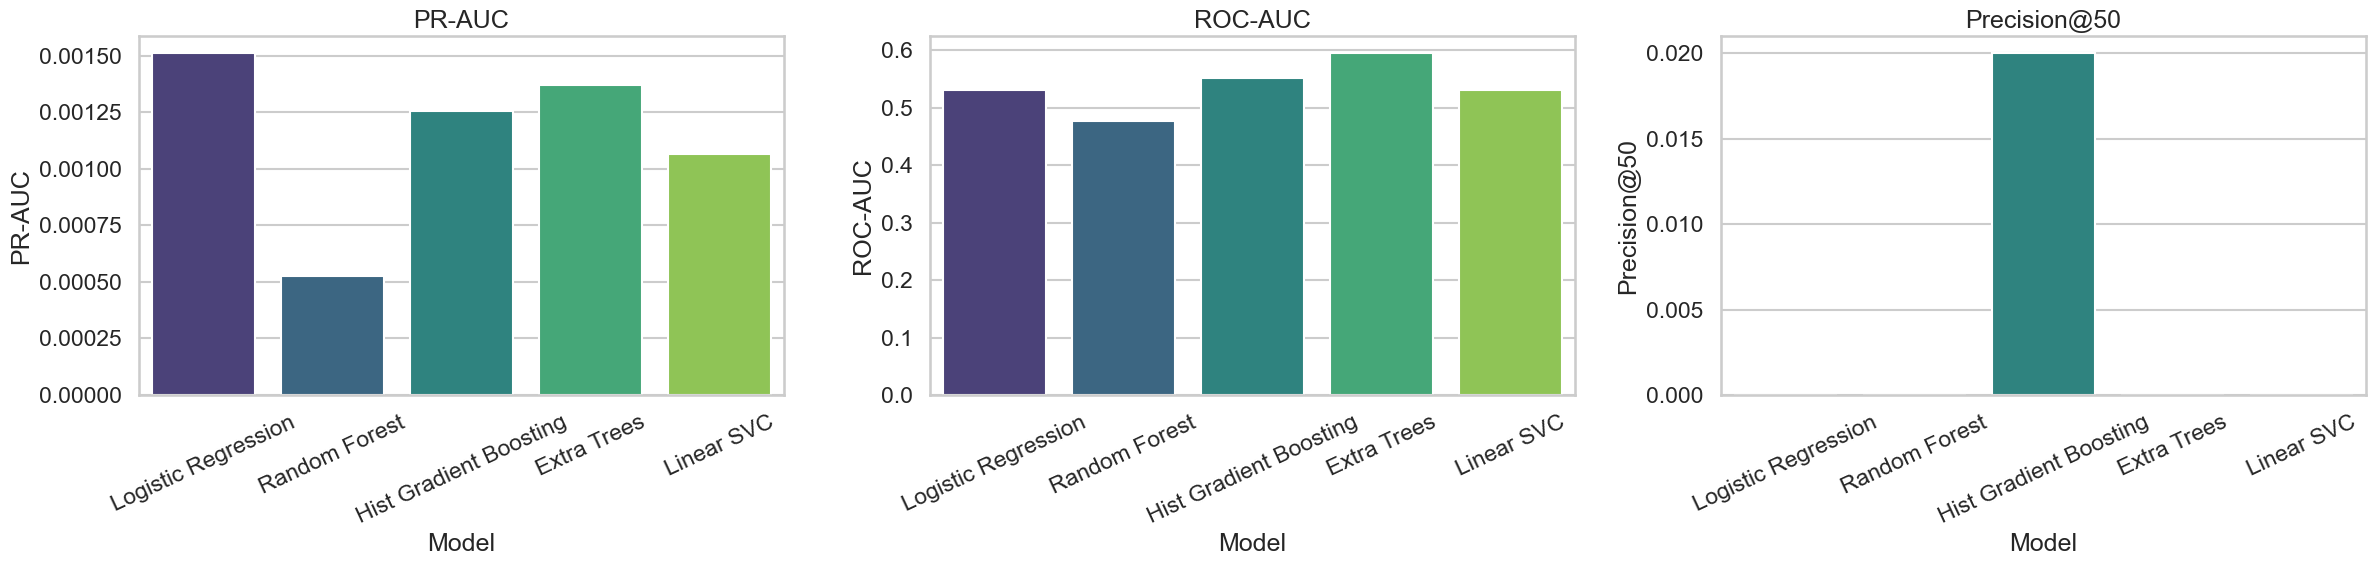

In [5]:
metric_plot_df = default_summary.melt(
    id_vars=['model_name', 'display_name'],
    value_vars=['pr_auc', 'roc_auc', 'precision_at_50'],
    var_name='metric',
    value_name='value',
)
metric_labels = {'pr_auc': 'PR-AUC', 'roc_auc': 'ROC-AUC', 'precision_at_50': 'Precision@50'}
metric_plot_df['metric_label'] = metric_plot_df['metric'].map(metric_labels)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for axis, metric_key in zip(axes, ['pr_auc', 'roc_auc', 'precision_at_50']):
    subset = metric_plot_df[metric_plot_df['metric'] == metric_key]
    sns.barplot(data=subset, x='display_name', y='value', hue='display_name', dodge=False, legend=False, palette='viridis', ax=axis)
    axis.set_title(metric_labels[metric_key])
    axis.set_xlabel('Model')
    axis.set_ylabel(metric_labels[metric_key])
    axis.tick_params(axis='x', rotation=25)

plt.tight_layout()
fig.savefig(overview_plot_path, bbox_inches='tight')
plt.show()


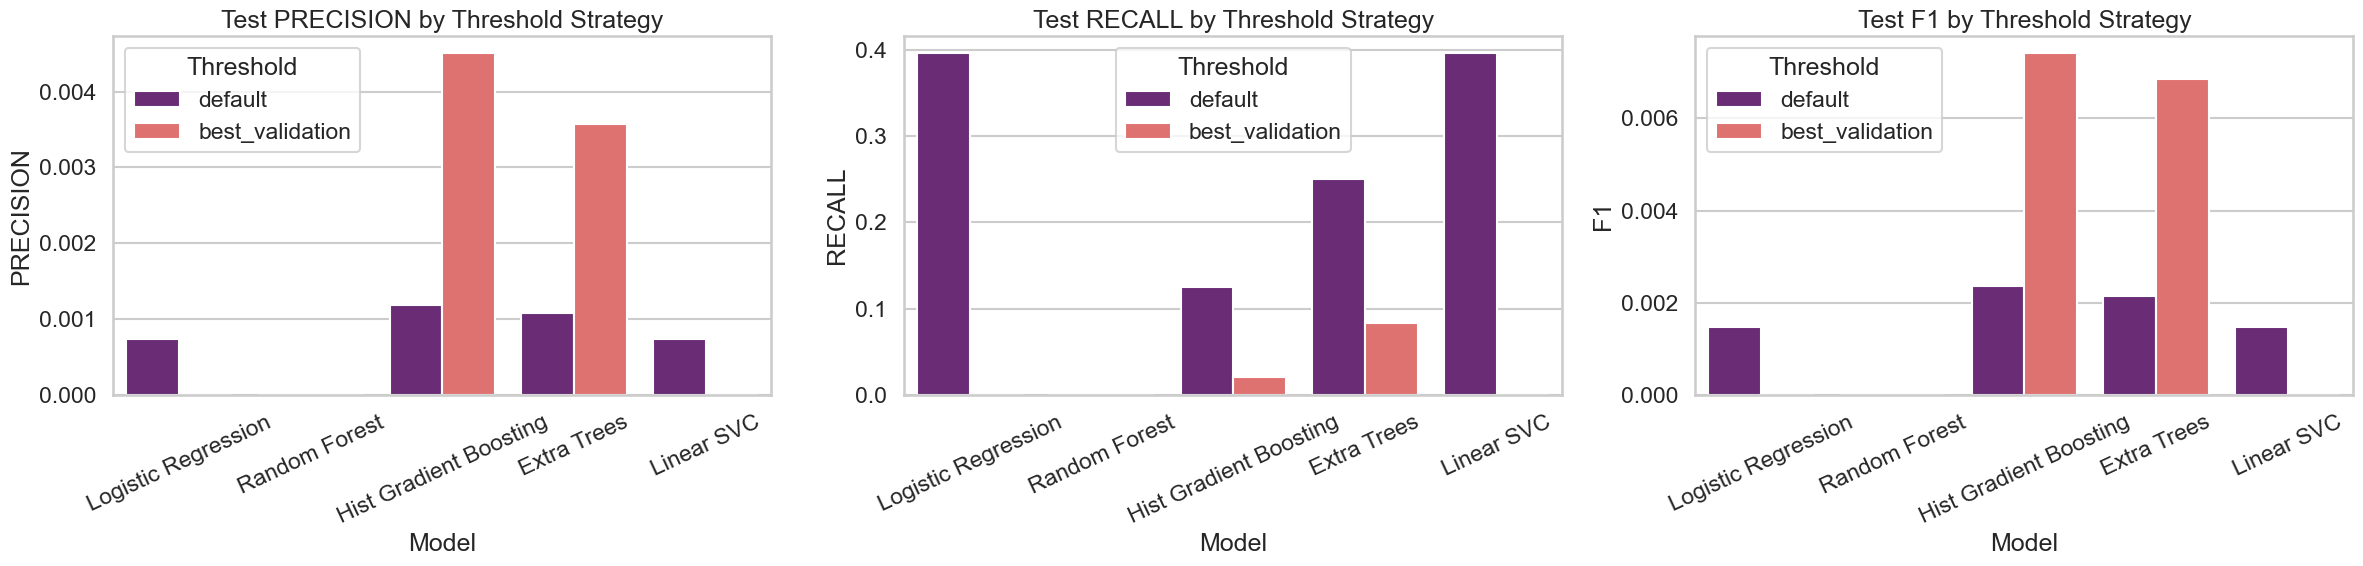

In [6]:
threshold_comparison = pd.concat([default_summary, best_summary], ignore_index=True)
threshold_metric_df = threshold_comparison.melt(
    id_vars=['display_name', 'threshold_strategy'],
    value_vars=['precision', 'recall', 'f1'],
    var_name='metric',
    value_name='value',
)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for axis, metric_key in zip(axes, ['precision', 'recall', 'f1']):
    subset = threshold_metric_df[threshold_metric_df['metric'] == metric_key]
    sns.barplot(data=subset, x='display_name', y='value', hue='threshold_strategy', palette='magma', ax=axis)
    axis.set_title(f'Test {metric_key.upper()} by Threshold Strategy')
    axis.set_xlabel('Model')
    axis.set_ylabel(metric_key.upper())
    axis.tick_params(axis='x', rotation=25)
    axis.legend(title='Threshold')

plt.tight_layout()
fig.savefig(threshold_plot_path, bbox_inches='tight')
plt.show()


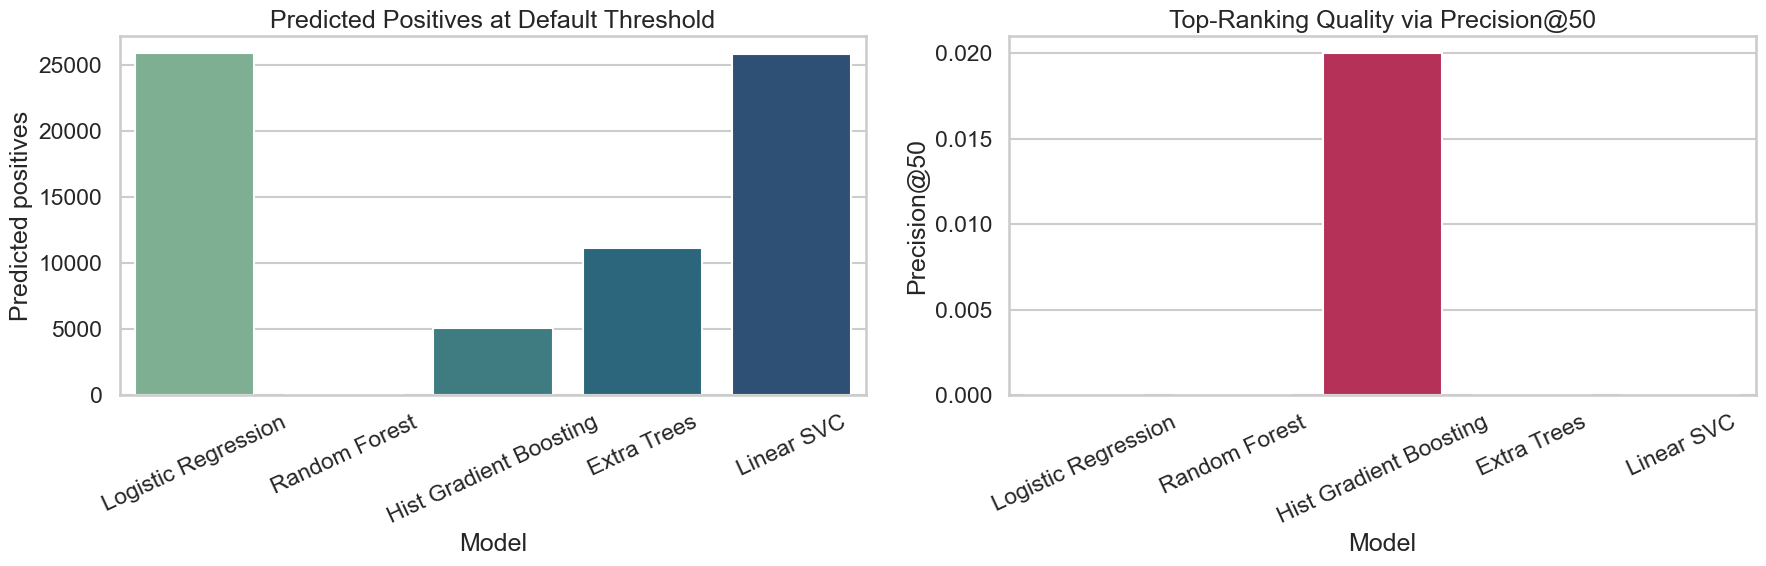

In [7]:
ranking_plot_df = default_summary[['display_name', 'predicted_positives', 'precision_at_50']].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=ranking_plot_df, x='display_name', y='predicted_positives', hue='display_name', dodge=False, legend=False, palette='crest', ax=axes[0])
axes[0].set_title('Predicted Positives at Default Threshold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Predicted positives')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=ranking_plot_df, x='display_name', y='precision_at_50', hue='display_name', dodge=False, legend=False, palette='rocket', ax=axes[1])
axes[1].set_title('Top-Ranking Quality via Precision@50')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Precision@50')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
fig.savefig(ranking_plot_path, bbox_inches='tight')
plt.show()


## Summary

This notebook compares the saved evaluation artifacts from [08_linear_svc.ipynb](08_linear_svc.ipynb) and the earlier model notebooks. At this stage, the most useful outputs are the ranked summary tables and the metric-overview plots in `results/model_comparison/`, because they make the trade-offs between ranking quality, recall, and threshold behavior explicit before choosing the final model.

Persisted comparison artifacts are written to `results/model_comparison/`.
